### ouverture des fichiers et jointures 

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from pathlib import Path
from fonction import *
import seaborn as sns
import numpy as np

In [2]:
fp = Path("data") / "raw" / "communes" / "ADE_4-0_GPKG_WGS84G_FRA-ED2025-11-20.gpkg"
if not fp.exists():
	raise FileNotFoundError(f"File not found: {fp.resolve()}")
communes = gpd.read_file(fp, layer='commune')

fp = Path("data") / "intermediate" / "datagouv" / "swimonthly_combined_1958to2025.gpkg"
if not fp.exists():
	raise FileNotFoundError(f"File not found: {fp.resolve()}")
swi_monthly = gpd.read_file(fp)


fp = Path("data") / "intermediate" / "meteo_france" / "meteo_france_combined.gpkg"
if not fp.exists():
    raise FileNotFoundError(f"File not found: {fp.resolve()}")
meteo_france = gpd.read_file(fp)


fp = Path("data") / "intermediate" / "argile" / "argile.gpkg"
if not fp.exists():
    raise FileNotFoundError(f"File not found: {fp.resolve()}")
argile = gpd.read_file(fp)

In [3]:
display(communes.head())

,cleabs,nom_officiel,nom_officiel_en_majuscules,statut,code_insee,population,date_du_recensement,organisme_recenseur,code_insee_du_canton,code_insee_de_l_arrondissement,code_insee_du_departement,code_insee_de_la_region,codes_siren_des_epci,code_siren,code_postal,superficie_cadastrale,geometry
0,COMMUNE_0000000000001001,L'Abergement-Clémenciat,L'ABERGEMENT-CLEMENCIAT,Commune simple,01001,859,2022-01-01,INSEE,0108,012,01,84,200069193,210100012,01400,1590,"MULTIPOLYGON (((4.95841 46.15327, 4.95812 46.1..."
1,COMMUNE_0000000000001002,L'Abergement-de-Varey,L'ABERGEMENT-DE-VAREY,Commune simple,01002,273,2022-01-01,INSEE,0101,011,01,84,240100883,210100020,01640,920,"MULTIPOLYGON (((5.4302 45.98277, 5.43012 45.98..."
2,COMMUNE_0000000000001004,Ambérieu-en-Bugey,AMBERIEU-EN-BUGEY,Commune simple,01004,15554,2022-01-01,INSEE,0101,011,01,84,240100883,210100046,01500,2460,"MULTIPOLYGON (((5.40882 45.94206, 5.4085 45.94..."
3,COMMUNE_0000000000001005,Ambérieux-en-Dombes,AMBERIEUX-EN-DOMBES,Commune simple,01005,1917,2022-01-01,INSEE,0122,012,01,84,200042497,210100053,01330,1590,"MULTIPOLYGON (((4.94298 45.97962, 4.94257 45.9..."
4,COMMUNE_0000000000001006,Ambléon,AMBLEON,Commune simple,01006,114,2022-01-01,INSEE,0104,011,01,84,200040350,210100061,01300,590,"MULTIPOLYGON (((5.57083 45.75338, 5.57219 45.7..."


In [4]:
swi_monthly['DATE'] = pd.to_datetime(swi_monthly['DATE']) - pd.offsets.MonthBegin(1)
swi_monthly = swi_monthly[swi_monthly['DATE'] >= '1960-01-01']
display(swi_monthly)

,DATE,LAMBX,LAMBY,PRENEI,PRELIQ,T,FF,Q,DLI,SSI,...,HTEURNEIGE,HTEURNEIGE6,HTEURNEIGEX,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,geometry
168164,1960-01-01,600,24010,5.5,98.9,7.396774,5.145161,5.581742,87057.7,8987.6,...,0.000355,0.0,0.035,0.006452,5.3,0.319419,0.000065,-2.1,13.3,POINT (60000 2401000)
168165,1960-01-01,760,23610,0.6,91.8,7.477419,6.616129,5.709613,86828.0,9751.3,...,0.000000,0.0,0.001,0.000000,0.6,0.263484,0.000194,-1.5,12.6,POINT (76000 2361000)
168166,1960-01-01,760,23930,0.3,91.5,7.583871,6.558065,5.743839,87214.9,9749.5,...,0.000000,0.0,0.001,0.000000,0.4,0.318710,0.000129,-1.4,12.9,POINT (76000 2393000)
168167,1960-01-01,760,24010,5.9,101.1,7.064516,5.238710,5.480290,85955.7,8996.8,...,0.000355,0.0,0.030,0.012903,5.7,0.321290,0.000323,-2.2,12.6,POINT (76000 2401000)
168168,1960-01-01,760,24090,5.8,100.3,7.196774,5.203226,5.517258,86361.2,8993.0,...,0.000290,0.0,0.027,0.012903,5.6,0.321452,0.000323,-2.1,12.8,POINT (76000 2409000)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7982859,2025-10-01,11960,17050,0.0,44.5,18.122581,2.538710,8.597774,91740.2,33351.6,...,0.000000,0.0,0.000,0.000000,0.0,0.190774,0.000000,12.5,25.8,POINT (1196000 1705000)
7982860,2025-10-01,11960,17130,0.0,27.8,16.987097,2.683871,7.945290,92372.0,33203.6,...,0.000000,0.0,0.000,0.000000,0.0,0.194065,0.000000,9.3,25.8,POINT (1196000 1713000)
7982861,2025-10-01,11960,17210,0.0,27.8,16.967742,2.683871,7.937194,92353.8,33201.1,...,0.000000,0.0,0.000,0.000000,0.0,0.186806,0.000000,9.3,25.8,POINT (1196000 1721000)
7982862,2025-10-01,11960,17290,0.0,27.8,16.967742,2.683871,7.937194,92353.8,33201.1,...,0.000000,0.0,0.000,0.000000,0.0,0.204161,0.000000,9.3,25.8,POINT (1196000 1729000)


In [5]:

meteo_france['SWI_UNIF_MENS'] = meteo_france['SWI_UNIF_MENS'].str.replace(',', '.').astype(np.float64)
display(meteo_france)

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,geometry
0,2,641374,7106309,1960-01-01,0.863,POINT (641374 7106309)
1,2,641374,7106309,1960-02-01,0.876,POINT (641374 7106309)
2,2,641374,7106309,1960-03-01,0.856,POINT (641374 7106309)
3,2,641374,7106309,1960-04-01,0.757,POINT (641374 7106309)
4,2,641374,7106309,1960-05-01,0.673,POINT (641374 7106309)
...,...,...,...,...,...,...
7005175,9892,1215772,6046242,2024-08-01,-0.019,POINT (1215772 6046242)
7005176,9892,1215772,6046242,2024-09-01,0.007,POINT (1215772 6046242)
7005177,9892,1215772,6046242,2024-10-01,0.170,POINT (1215772 6046242)
7005178,9892,1215772,6046242,2024-11-01,0.126,POINT (1215772 6046242)


In [6]:
print(argile.crs)
cols_argile = ["geometry", "ALEA", "NIVEAU", "DPT"]
argile=argile.to_crs(swi_monthly.crs)

EPSG:3857


In [7]:
print(meteo_france.crs)
cols_meteo = ["DATE", "SWI_UNIF_MENS"]
meteo_france=meteo_france.to_crs(swi_monthly.crs)
print(swi_monthly.crs)
print(meteo_france.crs)

EPSG:2154
EPSG:27572
EPSG:27572


In [8]:
swi_monthly

,DATE,LAMBX,LAMBY,PRENEI,PRELIQ,T,FF,Q,DLI,SSI,...,HTEURNEIGE,HTEURNEIGE6,HTEURNEIGEX,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,geometry
168164,1960-01-01,600,24010,5.5,98.9,7.396774,5.145161,5.581742,87057.7,8987.6,...,0.000355,0.0,0.035,0.006452,5.3,0.319419,0.000065,-2.1,13.3,POINT (60000 2401000)
168165,1960-01-01,760,23610,0.6,91.8,7.477419,6.616129,5.709613,86828.0,9751.3,...,0.000000,0.0,0.001,0.000000,0.6,0.263484,0.000194,-1.5,12.6,POINT (76000 2361000)
168166,1960-01-01,760,23930,0.3,91.5,7.583871,6.558065,5.743839,87214.9,9749.5,...,0.000000,0.0,0.001,0.000000,0.4,0.318710,0.000129,-1.4,12.9,POINT (76000 2393000)
168167,1960-01-01,760,24010,5.9,101.1,7.064516,5.238710,5.480290,85955.7,8996.8,...,0.000355,0.0,0.030,0.012903,5.7,0.321290,0.000323,-2.2,12.6,POINT (76000 2401000)
168168,1960-01-01,760,24090,5.8,100.3,7.196774,5.203226,5.517258,86361.2,8993.0,...,0.000290,0.0,0.027,0.012903,5.6,0.321452,0.000323,-2.1,12.8,POINT (76000 2409000)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7982859,2025-10-01,11960,17050,0.0,44.5,18.122581,2.538710,8.597774,91740.2,33351.6,...,0.000000,0.0,0.000,0.000000,0.0,0.190774,0.000000,12.5,25.8,POINT (1196000 1705000)
7982860,2025-10-01,11960,17130,0.0,27.8,16.987097,2.683871,7.945290,92372.0,33203.6,...,0.000000,0.0,0.000,0.000000,0.0,0.194065,0.000000,9.3,25.8,POINT (1196000 1713000)
7982861,2025-10-01,11960,17210,0.0,27.8,16.967742,2.683871,7.937194,92353.8,33201.1,...,0.000000,0.0,0.000,0.000000,0.0,0.186806,0.000000,9.3,25.8,POINT (1196000 1721000)
7982862,2025-10-01,11960,17290,0.0,27.8,16.967742,2.683871,7.937194,92353.8,33201.1,...,0.000000,0.0,0.000,0.000000,0.0,0.204161,0.000000,9.3,25.8,POINT (1196000 1729000)


In [9]:
meteo_france

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,geometry
0,2,641374,7106309,1960-01-01,0.863,POINT (588001.454 2673000.704)
1,2,641374,7106309,1960-02-01,0.876,POINT (588001.454 2673000.704)
2,2,641374,7106309,1960-03-01,0.856,POINT (588001.454 2673000.704)
3,2,641374,7106309,1960-04-01,0.757,POINT (588001.454 2673000.704)
4,2,641374,7106309,1960-05-01,0.673,POINT (588001.454 2673000.704)
...,...,...,...,...,...,...
7005175,9892,1215772,6046242,2024-08-01,-0.019,POINT (1171999.296 1617001.255)
7005176,9892,1215772,6046242,2024-09-01,0.007,POINT (1171999.296 1617001.255)
7005177,9892,1215772,6046242,2024-10-01,0.170,POINT (1171999.296 1617001.255)
7005178,9892,1215772,6046242,2024-11-01,0.126,POINT (1171999.296 1617001.255)


### jointure des bases


### Explication de la jointure

La jointure effectuée dans la cellule ci-dessous combine les données météorologiques de `meteo_france` avec les données de l'indice SWI (Soil Wetness Index) de `swi_monthly`. Voici les étapes principales de cette jointure :

1. **Groupement par date** :
    - Les données de `meteo_france` sont regroupées par la colonne `DATE`. Cela permet de traiter les données pour chaque mois séparément.

2. **Filtrage des données SWI** :
    - Pour chaque date, les données correspondantes dans `swi_monthly` sont filtrées pour ne conserver que celles ayant la même date que le groupe courant de `meteo_france`.

3. **Jointure spatiale** :
    - Une jointure spatiale est réalisée entre les données météorologiques (`meteo_d`) et les données SWI filtrées (`swi_d`) en utilisant la méthode `sjoin_nearest` de GeoPandas.
    - Cette méthode associe chaque point de `meteo_d` au point le plus proche dans `swi_d`, en fonction de leur distance géographique.
    - Une distance maximale (`max_distance=100`) est définie pour limiter l'association à des points proches (à ajuster selon la résolution des données).

4. **Concaténation des résultats** :
    - Les résultats de chaque jointure (par date) sont concaténés pour former un GeoDataFrame final, `gdf_join`.

5. **Nettoyage des colonnes** :
    - Les colonnes inutiles issues de la jointure, comme `LAMBX_right`, `LAMBY_right`, `geometry_right`, et `index_right`, sont supprimées.
    - Les colonnes restantes sont renommées pour éviter les doublons et clarifier les données.

6. **Export des données** :
    - Le GeoDataFrame final est sauvegardé dans un fichier GeoPackage (`jointure_meteo_swimonthly_full.gpkg`) pour une utilisation ultérieure.

Cette jointure permet de combiner les informations météorologiques et les indices SWI pour chaque point géographique, facilitant ainsi l'analyse des relations entre les conditions météorologiques et l'humidité des sols.
```

In [10]:
output_fp = Path("data") / "processed" / "jointure_meteo_swimonthly_full.gpkg"
output_fp.parent.mkdir(parents=True, exist_ok=True)



if output_fp.exists():
    print(" Jointure déjà existante — chargement depuis le disque.")
    gdf_join = gpd.read_file(output_fp)



else:
    print(" Jointure inexistante — calcul de la jointure spatio-temporelle.")

    res = []

    for d, meteo_d in meteo_france.groupby("DATE"):
        swi_d = swi_monthly[swi_monthly["DATE"] == d]
        if swi_d.empty:
            continue

        tmp = gpd.sjoin_nearest(
            meteo_d,
            swi_d.drop(columns=["DATE"]),   # évite DATE_left / DATE_right
            how="left",
            max_distance=100,               # à adapter à la maille
        )

        res.append(tmp)

    gdf_join = gpd.GeoDataFrame(
        pd.concat(res, ignore_index=True),
        crs=meteo_france.crs
    )


    gdf_join = (
        gdf_join
        .sort_values("DATE")
        .drop_duplicates(subset=["NUMERO", "DATE"], keep="first")
    )


    cols_to_drop = [
        "LAMBX_right",
        "LAMBY_right",
        "geometry_right",
        "index_right",
    ]

    gdf_join = gdf_join.drop(
        columns=[c for c in cols_to_drop if c in gdf_join.columns]
    )

    gdf_join = gdf_join.rename(columns={
        "LAMBX_left": "LAMBX",
        "LAMBY_left": "LAMBY"
    })


    gdf_join.to_file(output_fp, driver="GPKG")
    print(f" Jointure sauvegardée : {output_fp}")



display(gdf_join)

 Jointure inexistante — calcul de la jointure spatio-temporelle.
 Jointure sauvegardée : data\processed\jointure_meteo_swimonthly_full.gpkg


,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,geometry,PRENEI,PRELIQ,T,FF,...,RESR_NEIGE6,HTEURNEIGE,HTEURNEIGE6,HTEURNEIGEX,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H
0,2,641374,7106309,1960-01-01,0.863,POINT (588001.454 2673000.704),4.9,51.5,4.829032,6.822581,...,0.303226,0.001710,0.001839,0.024,0.096774,4.0,0.287032,0.002484,-7.2,11.6
5997,7119,635809,6442801,1960-01-01,1.081,POINT (587999.304 2008998.388),20.2,96.4,1.990323,2.061290,...,4.022581,0.030935,0.031323,0.174,0.177419,38.0,0.298742,0.012194,-13.1,11.7
5996,7118,627817,6442868,1960-01-01,1.100,POINT (579999.298 2008998.399),22.7,119.8,2.783871,1.996774,...,4.622581,0.032935,0.033581,0.180,0.203226,50.2,0.264548,0.012129,-12.8,12.2
5995,7117,619825,6442935,1960-01-01,1.095,POINT (571999.291 2008998.458),21.8,115.4,3.277419,2.083871,...,4.332258,0.030839,0.031226,0.170,0.180645,45.7,0.284097,0.010065,-12.2,13.0
5994,7116,611833,6443002,1960-01-01,1.086,POINT (563999.284 2008998.565),23.8,108.4,3.490323,2.174194,...,4.690323,0.032871,0.033323,0.179,0.183871,41.7,0.293774,0.008742,-11.5,13.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6999211,3831,805955,6713138,2024-12-01,0.927,POINT (756000.273 2280998.1),0.9,68.4,4.016129,2.809677,...,0.000000,0.000000,0.000000,0.000,0.000000,0.9,0.344613,0.000097,-3.9,12.8
6999212,3832,813948,6713070,2024-12-01,0.908,POINT (763999.644 2280998.186),1.5,71.1,2.861290,3.348387,...,0.000000,0.000000,0.000000,0.001,0.000000,1.8,0.324968,0.000613,-5.0,11.4
6999213,3833,821942,6713002,2024-12-01,0.923,POINT (772000.016 2280998.33),3.2,71.2,2.835484,3.409677,...,0.000000,0.000000,0.000000,0.001,0.000000,3.9,0.321000,0.000516,-4.8,11.5
6999207,3827,773980,6713410,2024-12-01,0.973,POINT (723999.802 2280998.23),0.0,64.9,4.154839,2.825806,...,0.000000,0.000000,0.000000,0.000,0.000000,0.0,0.375032,0.000774,-2.5,13.3


In [11]:
argile

,ALEA,DPT,NIVEAU,geometry
0,Faible,29,1.0,"POLYGON ((48327.467 2410619.543, 48378.067 241..."
1,Faible,29,1.0,"POLYGON ((48250.28 2410635.844, 48291.446 2410..."
2,Faible,29,1.0,"POLYGON ((48883.726 2410561.982, 48882.224 241..."
3,Faible,29,1.0,"POLYGON ((48814.423 2410895.518, 48809.806 241..."
4,Faible,29,1.0,"POLYGON ((50025.768 2410812.088, 50015.999 241..."
...,...,...,...,...
1180531,Faible,202,1.0,"POLYGON ((1195311.693 1729027.041, 1195362.574..."
1180532,Faible,202,1.0,"POLYGON ((1196686.075 1723499.275, 1196682.969..."
1180533,Faible,202,1.0,"POLYGON ((1196725.172 1724402.792, 1196735.399..."
1180534,Faible,202,1.0,"POLYGON ((1196566.174 1725306.136, 1196578.161..."


In [12]:

output_fp = Path("data") / "processed" / "jointure_meteo_swi_argile_nearest.gpkg"
output_fp.parent.mkdir(parents=True, exist_ok=True)

cols_argile = ["geometry", "ALEA", "NIVEAU", "DPT"]


if output_fp.exists():
    print(" Jointure MF + SWI + Argile déjà existante — chargement.")
    gdf_join_argile = gpd.read_file(output_fp)

# -------------------------------------------------
# 2) Sinon → calcul
# -------------------------------------------------

else:
    print(" Calcul de la jointure MF + SWI + Argile (nearest, par année).")

    # CRS
    if argile.crs != gdf_join.crs:
        argile = argile.to_crs(gdf_join.crs)

    # Ajout colonne année (sécurité)
    gdf_join = gdf_join.copy()
    gdf_join["YEAR"] = gdf_join["DATE"].dt.year

    res = []

    for y, gdf_y in gdf_join.groupby("YEAR"):
        print(f"  → année {y}")

        tmp = gpd.sjoin_nearest(
            gdf_y,
            argile[cols_argile],
            how="left",
            distance_col="dist_to_argile"
        )

        # sécurité ex æquo
        tmp = (
            tmp
            .sort_values("dist_to_argile")
            .drop_duplicates(subset=["NUMERO", "DATE"], keep="first")
        )

        res.append(tmp)

    gdf_join_argile = gpd.GeoDataFrame(
        pd.concat(res, ignore_index=True),
        crs=gdf_join.crs
    )

    # Nettoyage
    gdf_join_argile = gdf_join_argile.drop(
        columns=[c for c in ["index_right"] if c in gdf_join_argile.columns]
    )
    gdf_join_argile.loc[gdf_join_argile['dist_to_argile'] > 1000, 'NIVEAU'] = 0   #on met 0 au-delà de 1km d'une zone argileuse
    gdf_join_argile.loc[gdf_join_argile['dist_to_argile'] > 1000, 'ALEA'] = 'Aucun'
    

    # -------------------------------------------------
    # 3) Sauvegarde
    # -------------------------------------------------
    gdf_join_argile.to_file(output_fp, driver="GPKG")
    print(f" Sauvegarde terminée : {output_fp}")

# -------------------------------------------------
# 4) Résultat
# -------------------------------------------------

display(gdf_join_argile)

 Calcul de la jointure MF + SWI + Argile (nearest, par année).
  → année 1960
  → année 1961
  → année 1962
  → année 1963
  → année 1964
  → année 1965
  → année 1966
  → année 1967
  → année 1968
  → année 1969
  → année 1970
  → année 1971
  → année 1972
  → année 1973
  → année 1974
  → année 1975
  → année 1976
  → année 1977
  → année 1978
  → année 1979
  → année 1980
  → année 1981
  → année 1982
  → année 1983
  → année 1984
  → année 1985
  → année 1986
  → année 1987
  → année 1988
  → année 1989
  → année 1990
  → année 1991
  → année 1992
  → année 1993
  → année 1994
  → année 1995
  → année 1996
  → année 1997
  → année 1998
  → année 1999
  → année 2000
  → année 2001
  → année 2002
  → année 2003
  → année 2004
  → année 2005
  → année 2006
  → année 2007
  → année 2008
  → année 2009
  → année 2010
  → année 2011
  → année 2012
  → année 2013
  → année 2014
  → année 2015
  → année 2016
  → année 2017
  → année 2018
  → année 2019
  → année 2020
  → année 2021
  → ann

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,geometry,PRENEI,PRELIQ,T,FF,...,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,YEAR,ALEA,NIVEAU,DPT,dist_to_argile
0,3827,773980,6713410,1960-12-01,0.982,POINT (723999.802 2280998.23),5.7,59.2,1.941935,3.132258,...,6.1,0.370645,0.003516,-5.7,12.0,1960,Moyen,2.0,89,0.000000
1,3826,765986,6713478,1960-12-01,0.977,POINT (715999.436 2280998.385),4.8,58.9,2.216129,3.254839,...,5.2,0.351065,0.002323,-5.4,12.3,1960,Moyen,2.0,89,0.000000
2,3825,757993,6713546,1960-12-01,0.973,POINT (708000.072 2280998.598),4.4,58.9,2.338710,3.300000,...,4.9,0.334355,0.001806,-5.2,12.4,1960,Moyen,2.0,89,0.000000
3,3824,749999,6713614,1960-12-01,0.973,POINT (699999.708 2280998.852),4.4,58.9,2.338710,3.300000,...,4.9,0.324452,0.001806,-5.2,12.4,1960,Faible,1.0,89,0.000000
4,5323,717146,6609971,1960-09-01,0.449,POINT (667998.94 2176998.552),0.0,73.6,13.356667,1.530000,...,0.0,0.263533,0.000000,2.3,24.0,1960,Moyen,2.0,3,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7005175,7245,363949,6429068,2024-08-01,0.124,POINT (315997.597 1992998.292),0.0,37.5,20.451613,1.880645,...,0.0,0.144290,0.000000,9.6,37.0,2024,Aucun,0.0,33,24729.333576
7005176,7245,363949,6429068,2024-03-01,1.042,POINT (315997.597 1992998.292),0.0,160.8,10.851613,2.603226,...,0.0,0.222710,0.000000,2.0,22.7,2024,Aucun,0.0,33,24729.333576
7005177,7245,363949,6429068,2024-12-01,0.695,POINT (315997.597 1992998.292),0.0,72.5,8.048387,2.909677,...,0.0,0.206065,0.000000,0.8,16.1,2024,Aucun,0.0,33,24729.333576
7005178,7245,363949,6429068,2024-05-01,0.770,POINT (315997.597 1992998.292),0.0,94.9,15.264516,2.796774,...,0.0,0.191290,0.000000,9.2,27.6,2024,Aucun,0.0,33,24729.333576


### STATS descriptive 

| Nom du champ | Descriptif                                                                                                                     | Unité   | Précision |
|--------------|-------------------------------------------------------------------------------------------------------------------------------|---------|-----------|
| DATE         | Date de la mesure                                                                                                             | AAAAMMJJ|           |
| PRENEI       | Précipitations solides, cumul quotidien ]06UTC-06UTC]                                                                        | mm      | 1/10      |
| PRELIQ       | Précipitations liquides, cumul quotidien ]06UTC-06UTC]                                                                       | mm      | 1/10      |
| T            | Température moyenne quotidienne ]00UTC-00UTC]                                                                                | °C      | 1/10      |
| FF           | Vent moyen quotidien ]00UTC-00UTC]                                                                                           | m/s     | 1/10      |
| Q            | Humidité spécifique moyenne quotidienne ]00UTC-00UTC]                                                                        | g/kg    |           |
| DLI          | Rayonnement atmosphérique, cumul quotidien ]00UTC-00UTC]                                                                     | J/cm²   |           |
| SSI          | Rayonnement visible, cumul quotidien ]00UTC-00UTC]                                                                           | J/cm²   |           |
| HU           | Humidité relative moyenne quotidienne ]00UTC-00UTC]                                                                          | %       |           |
| EVAP         | Evapotranspiration totale, cumul quotidien ]06UTC-06UTC]                                                                     | mm      | 1/10      |
| ETP          | Evapotranspiration potentielle (formule de Penman-Monteith)                                                                 | mm      | 1/10      |
| PE           | Pluies efficaces, cumul quotidien ]06UTC-06UTC]                                                                              | mm      | 1/10      |
| SWI          | Indice d'humidité des sols, moyenne quotidienne [06UTC-06UTC]                                                                | %       |           |
| SSWI_10J     | Indice de sécheresse de l’humidité des sols intégré sur 10 jours (jour J et 9 jours précédents)                             | -       |           |
| DRAINC       | Drainage, cumul quotidien ]06UTC-06UTC]                                                                                      | mm      | 1/10      |
| RUNC         | Ruissellement, cumul quotidien ]06UTC-06UTC]                                                                                | mm      | 1/10      |
| RESR_NEIGE   | Équivalent en eau du manteau neigeux, moyenne quotidienne [06UTC-06UTC]                                                      | mm      | 1/10      |
| RESR_NEIGE6  | Équivalent en eau du manteau neigeux à 06 UTC                                                                               | mm      | 1/10      |
| HTEURNEIGE   | Épaisseur du manteau neigeux, moyenne quotidienne [06UTC-06UTC]                                                              | m       |           |
| HTEURNEIGE6  | Épaisseur du manteau neigeux à 06 UTC                                                                                       | m       |           |
| HTEURNEIGEX  | Épaisseur du manteau neigeux horaire maximum au cours de la journée                                                         | m       |           |
| SNOW_FRAC    | Fraction de maille recouverte par la neige, moyenne quotidienne [06UTC-06UTC]                                               | %       |           |
| ECOULEMENT   | Écoulement à la base du manteau neigeux, cumul quotidien ]06UTC-06UTC]                                                      | mm      | 1/10      |
| WG_RACINE    | Contenu en eau liquide dans la couche racinaire à 06 UTC                                                                    | m³/m³   |           |
| WGI_RACINE   | Contenu en eau gelée dans la couche racinaire à 06 UTC                                                                      | m³/m³   |           |
| TINF_H       | Température minimale des 24 températures horaires, période ]18UTC-18UTC]                                                    | °C      | 1/10      |
| TSUP_H       | Température maximale des 24 températures horaires, période ]06UTC-06UTC]                                                    | °C      | 1/10      |
| LAMBX        | Coordonnée du point de grille en Lambert II étendu (hectomètres)                                                            | hm      |           |
| LAMBY        | Coordonnée du point de grille en Lambert II étendu (hectomètres)                                                            | hm      |           |


In [13]:
gdf_join_argile.describe()

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,PRENEI,PRELIQ,T,FF,Q,...,SNOW_FRAC,ECOULEMENT,WG_RACINE,WGI_RACINE,TINF_H,TSUP_H,YEAR,NIVEAU,DPT,dist_to_argile
count,7.005180e+06,7.005180e+06,7.005180e+06,7005180,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,...,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06,7.005180e+06
mean,5.062152e+03,6.681970e+05,6.599673e+06,1992-06-16 02:05:32.307000,6.137139e-01,5.263857e+00,7.190963e+01,1.069087e+01,2.856835e+00,6.852953e+00,...,3.786155e-02,6.551052e+00,2.717349e-01,2.525513e-03,1.198937e+00,2.165187e+01,1.992000e+03,1.653268e+00,4.717737e+01,2.988602e+02
min,2.000000e+00,1.114670e+05,6.046242e+06,1960-01-01 00:00:00,-5.700000e-02,0.000000e+00,0.000000e+00,-1.434516e+01,2.096774e-01,1.049464e+00,...,0.000000e+00,0.000000e+00,8.140000e-02,0.000000e+00,-3.020000e+01,-6.800000e+00,1.960000e+03,0.000000e+00,1.000000e+00,0.000000e+00
25%,2.414000e+03,4.996790e+05,6.393569e+06,1976-03-24 06:00:00,3.250000e-01,0.000000e+00,3.690000e+01,5.929032e+00,2.093548e+00,4.955071e+00,...,0.000000e+00,0.000000e+00,2.385484e-01,0.000000e+00,-3.400000e+00,1.540000e+01,1.976000e+03,1.000000e+00,2.300000e+01,0.000000e+00
50%,5.241000e+03,6.636830e+05,6.616330e+06,1992-06-16 00:00:00,6.620000e-01,0.000000e+00,6.230000e+01,1.035161e+01,2.716667e+00,6.440220e+00,...,0.000000e+00,0.000000e+00,2.749643e-01,0.000000e+00,9.000000e-01,2.170000e+01,1.992000e+03,2.000000e+00,4.400000e+01,0.000000e+00
75%,7.630000e+03,8.379290e+05,6.802491e+06,2008-09-08 12:00:00,9.060000e-01,1.200000e+00,9.540000e+01,1.581935e+01,3.454839e+00,8.802000e+00,...,0.000000e+00,1.300000e+00,3.076071e-01,4.000000e-04,6.500000e+00,2.770000e+01,2.008000e+03,2.000000e+00,6.600000e+01,1.043437e+02
max,9.892000e+03,1.240867e+06,7.106309e+06,2024-12-01 00:00:00,1.542000e+00,6.777000e+02,1.107100e+03,2.837097e+01,1.282069e+01,1.603855e+01,...,1.000000e+00,1.251500e+03,4.179333e-01,2.129355e-01,2.280000e+01,4.310000e+01,2.024000e+03,3.000000e+00,2.020000e+02,2.472933e+04
std,2.917439e+03,2.203358e+05,2.397082e+05,NaN,3.272674e-01,1.991311e+01,5.021953e+01,6.147450e+00,1.054441e+00,2.309131e+00,...,1.353921e-01,2.835926e+01,4.774404e-02,1.027461e-02,6.512080e+00,7.462434e+00,1.876166e+01,8.328971e-01,3.310445e+01,1.049525e+03


In [14]:
gdf_join_argile.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 7005180 entries, 0 to 7005179
Data columns (total 37 columns):
 #   Column          Dtype         
---  ------          -----         
 0   NUMERO          int64         
 1   LAMBX           int64         
 2   LAMBY           int64         
 3   DATE            datetime64[ms]
 4   SWI_UNIF_MENS   float64       
 5   geometry        geometry      
 6   PRENEI          float64       
 7   PRELIQ          float64       
 8   T               float64       
 9   FF              float64       
 10  Q               float64       
 11  DLI             float64       
 12  SSI             float64       
 13  HU              float64       
 14  EVAP            float64       
 15  ETP             float64       
 16  PE              float64       
 17  SWI             float64       
 18  SSWI_10J        float64       
 19  DRAINC          float64       
 20  RUNC            float64       
 21  RESR_NEIGE      float64       
 22  RESR_NEIGE

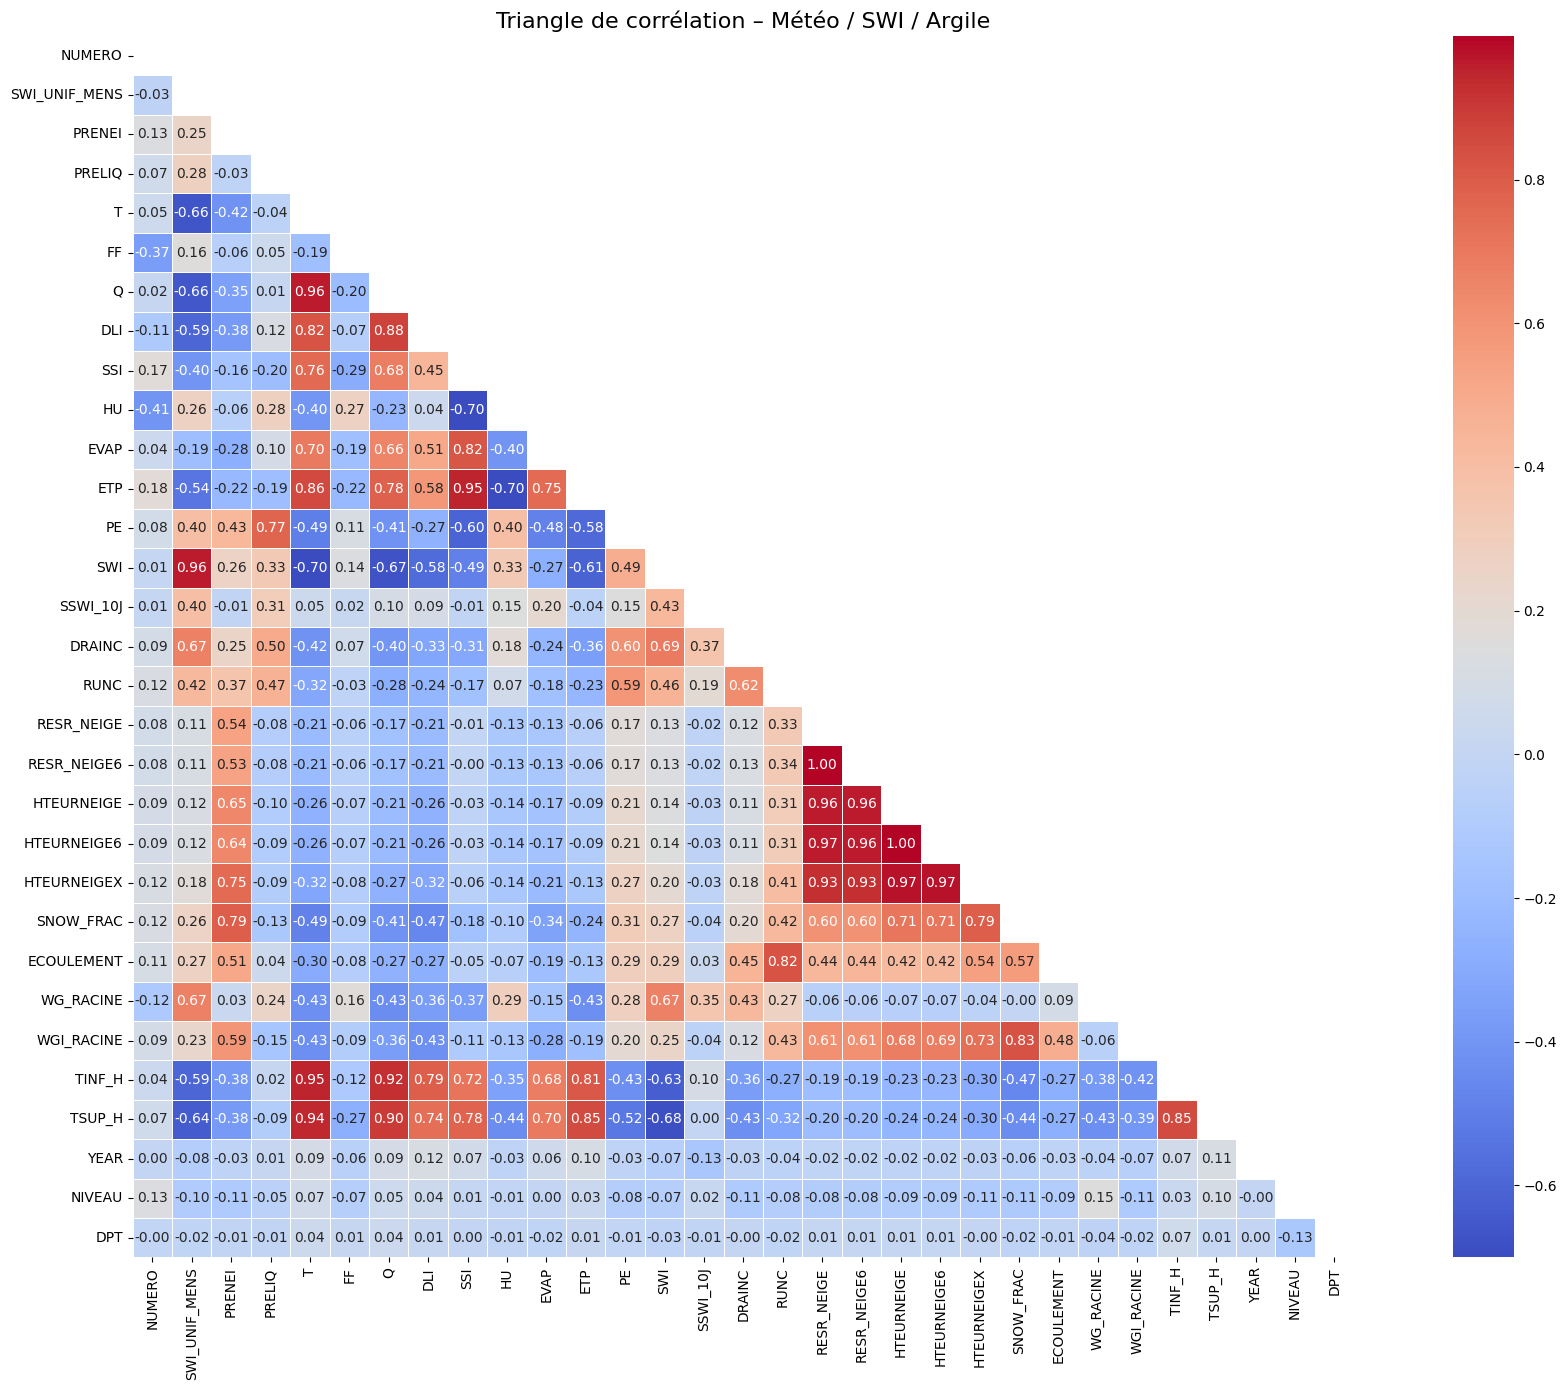

Top 10 des plus grandes corrélations avec la variable SWI :
SWI_UNIF_MENS    0.960589
T                0.695947
DRAINC           0.693557
TSUP_H           0.681959
WG_RACINE        0.670207
Q                0.668955
TINF_H           0.628107
ETP              0.607758
DLI              0.579849
SSI              0.493160
Name: SWI, dtype: float64


In [20]:
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt

numeric_cols = gdf_join_argile.select_dtypes(include=[np.number])

# Optionnel : enlever colonnes purement techniques
cols_to_exclude = ["LAMBX", "LAMBY", "dist_to_argile"]
numeric_cols = numeric_cols.drop(
    columns=[c for c in cols_to_exclude if c in numeric_cols.columns]
)


corr_matrix = numeric_cols.corr()



mask = np.triu(np.ones_like(corr_matrix, dtype=bool))



plt.figure(figsize=(20, 14))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    cbar=True,
    square=True,
    linewidths=0.5
)

plt.title("Triangle de corrélation – Météo / SWI / Argile", fontsize=16)
plt.tight_layout()
plt.show()

# Calculer les corrélations absolues avec la variable 'SWI'
correlations = corr_matrix['SWI'].abs().sort_values(ascending=False)

# Extraire les 10 plus grandes corrélations (en excluant 'SWI' lui-même)
top_10_correlations = correlations.drop('SWI').head(10)

# Afficher les résultats
print("Top 10 des plus grandes corrélations avec la variable SWI :")
print(top_10_correlations)

In [16]:
gdf_join_argile['dist_to_argile'].max()

np.float64(24729.33357589963)

In [17]:
meteo_france

,NUMERO,LAMBX,LAMBY,DATE,SWI_UNIF_MENS,geometry
0,2,641374,7106309,1960-01-01,0.863,POINT (588001.454 2673000.704)
1,2,641374,7106309,1960-02-01,0.876,POINT (588001.454 2673000.704)
2,2,641374,7106309,1960-03-01,0.856,POINT (588001.454 2673000.704)
3,2,641374,7106309,1960-04-01,0.757,POINT (588001.454 2673000.704)
4,2,641374,7106309,1960-05-01,0.673,POINT (588001.454 2673000.704)
...,...,...,...,...,...,...
7005175,9892,1215772,6046242,2024-08-01,-0.019,POINT (1171999.296 1617001.255)
7005176,9892,1215772,6046242,2024-09-01,0.007,POINT (1171999.296 1617001.255)
7005177,9892,1215772,6046242,2024-10-01,0.170,POINT (1171999.296 1617001.255)
7005178,9892,1215772,6046242,2024-11-01,0.126,POINT (1171999.296 1617001.255)
